<a href="https://colab.research.google.com/github/richab2005/MachineLearning-/blob/main/Assi5SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [2]:
data=load_breast_cancer()
df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [3]:
df.shape

(569, 31)

In [4]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [5]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [6]:
x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [7]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [8]:
x.shape

(569, 30)

In [9]:
y.shape

(569,)

In [10]:
x1=df[['mean radius','mean texture']]
x1

,mean radius,mean texture
0,17.99,10.38
1,20.57,17.77
2,19.69,21.25
3,11.42,20.38
4,20.29,14.34
...,...,...
564,21.56,22.39
565,20.13,28.25
566,16.60,28.08
567,20.60,29.33


In [11]:
x1.shape

(569, 2)

In [12]:
from sklearn.model_selection import train_test_split
x1_train,x1_test,y_train,y_test=train_test_split(x1,y,test_size=0.2)

In [13]:
print("x1_train",x1_train.shape)
print("y_train",y_train.shape)
print("x1_train",x1_test.shape)
print("y_test",y_test.shape)

x1_train (455, 2)
y_train (455,)
x1_train (114, 2)
y_test (114,)


/tmp/ipykernel_287/1953359426.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


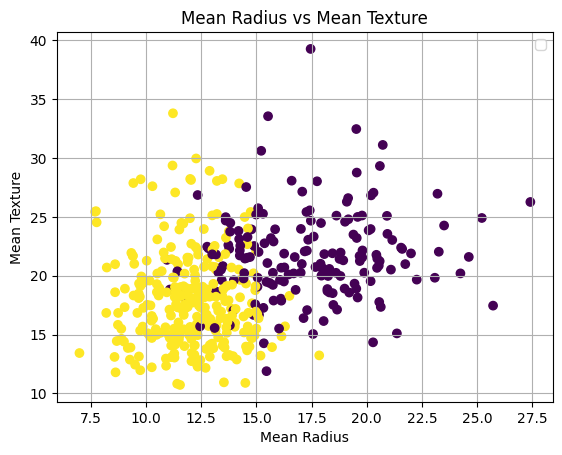

In [14]:
plt.scatter(x1_train['mean radius'],x1_train['mean texture'],c=y_train,cmap='viridis')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.title('Mean Radius vs Mean Texture')
plt.legend()
plt.grid()
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x1_train=sc.fit_transform(x1_train)
x1_test=sc.transform(x1_test)

In [16]:
from sklearn.svm import SVC
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(x1_train, y_train)


SVC(kernel='linear', random_state=42)

In [17]:
svm_rbf = SVC(kernel='rbf', C=1.0,random_state=42)
svm_rbf.fit(x1_train, y_train)

SVC(random_state=42)

In [18]:
svm_poly = SVC(kernel='poly', C=1.0,degree=3,coef0=0.0,random_state=42)
svm_poly.fit(x1_train, y_train)

SVC(kernel='poly', random_state=42)

In [19]:
y_pred_linear=svm_linear.predict(x1_test)
accuracy_linear = svm_linear.score(x1_test,y_pred_linear)
print(f"Accuracy with Linear Kernel: {accuracy_linear:.4f}")

Accuracy with Linear Kernel: 1.0000


In [20]:
y_pred_rbf=svm_rbf.predict(x1_test)
accuracy_rbf = svm_rbf.score(x1_test,y_pred_rbf)
print(f"Accuracy with rbf Kernel: {accuracy_rbf:.4f}")

Accuracy with rbf Kernel: 1.0000


In [21]:
y_pred_poly=svm_poly.predict(x1_test)
accuracy_poly = svm_poly.score(x1_test, y_pred_poly)
print(f"Accuracy with polynimoal Kernel: {accuracy_poly:.4f}")

Accuracy with polynimoal Kernel: 1.0000


confusion matrix for linear kernel [[36  6]
 [ 7 65]]


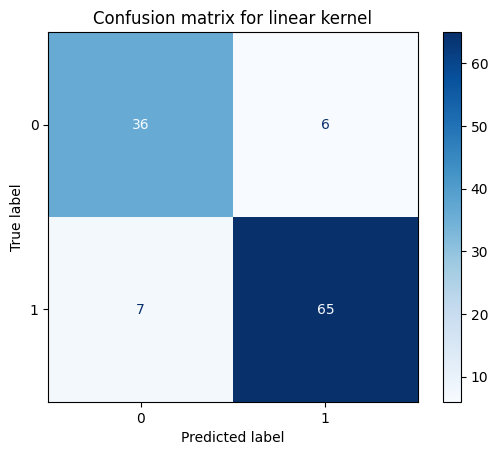

In [22]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm_linear=confusion_matrix(y_test,svm_linear.predict(x1_test))
print("confusion matrix for linear kernel",cm_linear)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_linear,display_labels=svm_linear.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix for linear kernel")
plt.show()

confusion matrix for rbf  kernel [[36  6]
 [ 7 65]]


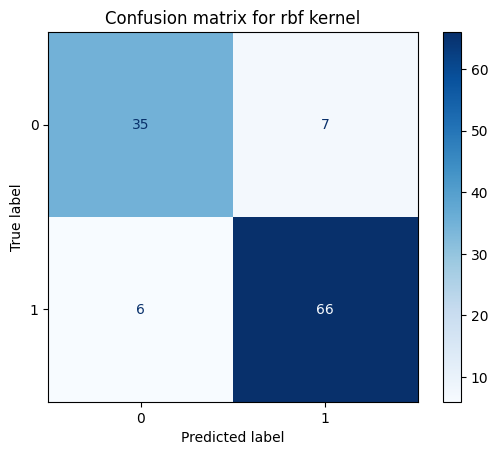

In [23]:
cm_rbf=confusion_matrix(y_test,svm_rbf.predict(x1_test))
print("confusion matrix for rbf  kernel",cm_linear)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_rbf,display_labels=svm_rbf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix for rbf kernel")
plt.show()

confusion matrix for poly kernel [[36  6]
 [ 7 65]]


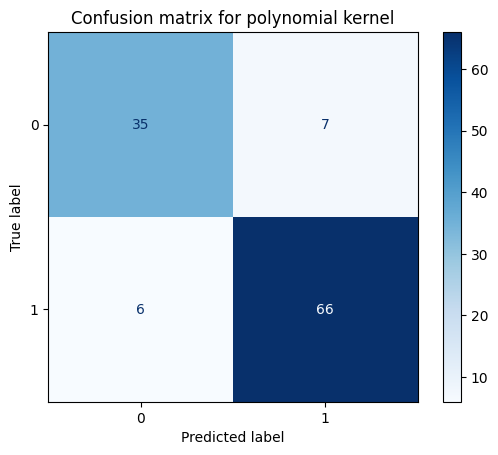

In [24]:
cm_ploy=confusion_matrix(y_test,svm_poly.predict(x1_test))
print("confusion matrix for poly kernel",cm_linear)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_rbf,display_labels=svm_poly.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix for polynomial kernel")
plt.show()

In [25]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_pred_linear)
print("classification report for linear kernel",cr)

classification report for linear kernel               precision    recall  f1-score   support

           0       0.84      0.86      0.85        42
           1       0.92      0.90      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.88      0.88       114
weighted avg       0.89      0.89      0.89       114



In [26]:
from sklearn.metrics import classification_report
cr_rbf=classification_report(y_test,y_pred_rbf)
print("classification report for rbf kernel",cr_rbf)

classification report for rbf kernel               precision    recall  f1-score   support

           0       0.85      0.83      0.84        42
           1       0.90      0.92      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.88      0.88       114
weighted avg       0.89      0.89      0.89       114



In [27]:
from sklearn.metrics import classification_report
cr_poly=classification_report(y_test,y_pred_poly)
print("classification report for rbf kernel",cr_poly)

classification report for rbf kernel               precision    recall  f1-score   support

           0       0.88      0.67      0.76        42
           1       0.83      0.94      0.88        72

    accuracy                           0.84       114
   macro avg       0.85      0.81      0.82       114
weighted avg       0.85      0.84      0.84       114



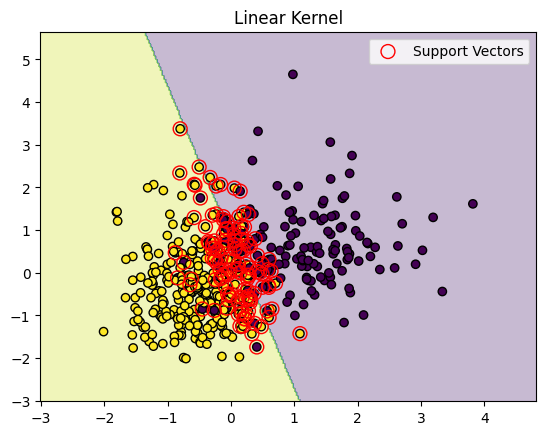

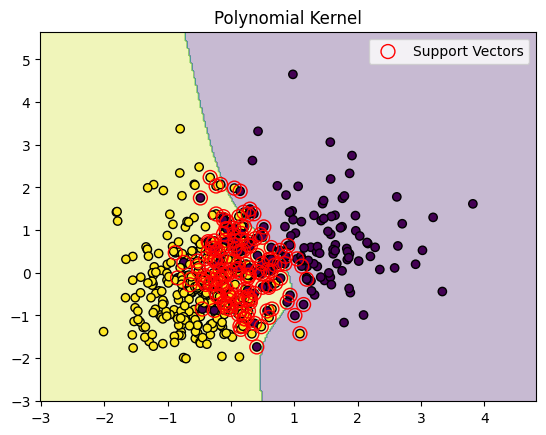

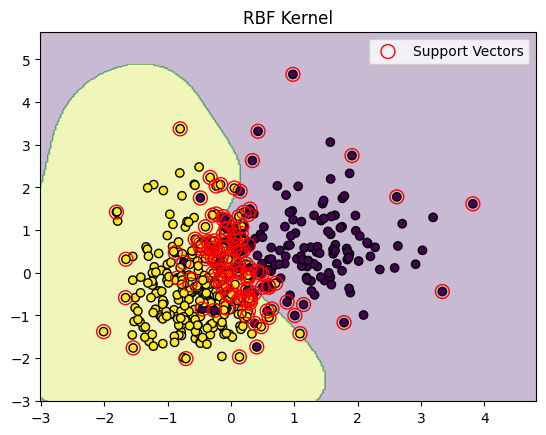

In [28]:

def plot_decision_boundary(model, X, y, title):
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
  np.linspace(y_min, y_max, 300))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
  plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
  s=100, facecolors='none', edgecolors='r', label='Support Vectors')
  plt.title(title)
  plt.legend()
  plt.show()

plot_decision_boundary(svm_linear, x1_train, y_train, "Linear Kernel")
plot_decision_boundary(svm_poly, x1_train, y_train, "Polynomial Kernel")
plot_decision_boundary(svm_rbf, x1_train, y_train, "RBF Kernel")

In [29]:
from inspect import Parameter
from sklearn.model_selection import GridSearchCV
Param_grid={'C':[1,10,100,1000],'kernel':['linear','rbf','poly']}
grid=GridSearchCV(SVC(kernel='linear'),Param_grid,refit=True,verbose=3)
grid.fit(x1_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END ................C=1, kernel=linear;, score=0.824 total time=   0.0s
[CV 2/5] END ................C=1, kernel=linear;, score=0.890 total time=   0.0s
[CV 3/5] END ................C=1, kernel=linear;, score=0.901 total time=   0.0s
[CV 4/5] END ................C=1, kernel=linear;, score=0.912 total time=   0.0s
[CV 5/5] END ................C=1, kernel=linear;, score=0.934 total time=   0.0s
[CV 1/5] END ...................C=1, kernel=rbf;, score=0.857 total time=   0.0s
[CV 2/5] END ...................C=1, kernel=rbf;, score=0.934 total time=   0.0s
[CV 3/5] END ...................C=1, kernel=rbf;, score=0.868 total time=   0.0s
[CV 4/5] END ...................C=1, kernel=rbf;, score=0.912 total time=   0.0s
[CV 5/5] END ...................C=1, kernel=rbf;, score=0.945 total time=   0.0s
[CV 1/5] END ..................C=1, kernel=poly;, score=0.835 total time=   0.0s
[CV 2/5] END ..................C=1, kernel=poly;

GridSearchCV(estimator=SVC(kernel='linear'),
             param_grid={'C': [1, 10, 100, 1000],
                         'kernel': ['linear', 'rbf', 'poly']},
             verbose=3)

In [30]:
print("Best Score:", grid.best_score_)
print("Best Parameters:", grid.best_params_)
print("Best Estimator:", grid.best_estimator_)

Best Score: 0.9032967032967033
Best Parameters: {'C': 1, 'kernel': 'rbf'}
Best Estimator: SVC(C=1)


In [31]:
from inspect import Parameter
from sklearn.model_selection import GridSearchCV
Param_grid={'C':[1,10,100,1000],'kernel':['linear','rbf','poly']}
grid_rbf=GridSearchCV(SVC(kernel='rbf'),Param_grid,refit=True,verbose=3)
grid_rbf.fit(x1_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END ................C=1, kernel=linear;, score=0.824 total time=   0.0s
[CV 2/5] END ................C=1, kernel=linear;, score=0.890 total time=   0.0s
[CV 3/5] END ................C=1, kernel=linear;, score=0.901 total time=   0.0s
[CV 4/5] END ................C=1, kernel=linear;, score=0.912 total time=   0.0s
[CV 5/5] END ................C=1, kernel=linear;, score=0.934 total time=   0.0s
[CV 1/5] END ...................C=1, kernel=rbf;, score=0.857 total time=   0.0s
[CV 2/5] END ...................C=1, kernel=rbf;, score=0.934 total time=   0.0s
[CV 3/5] END ...................C=1, kernel=rbf;, score=0.868 total time=   0.0s
[CV 4/5] END ...................C=1, kernel=rbf;, score=0.912 total time=   0.0s
[CV 5/5] END ...................C=1, kernel=rbf;, score=0.945 total time=   0.0s
[CV 1/5] END ..................C=1, kernel=poly;, score=0.835 total time=   0.0s
[CV 2/5] END ..................C=1, kernel=poly;

GridSearchCV(estimator=SVC(),
             param_grid={'C': [1, 10, 100, 1000],
                         'kernel': ['linear', 'rbf', 'poly']},
             verbose=3)

In [32]:
print("Best Score:", grid_rbf.best_score_)
print("Best Parameters:", grid_rbf.best_params_)
print("Best Estimator:", grid_rbf.best_estimator_)

Best Score: 0.9032967032967033
Best Parameters: {'C': 1, 'kernel': 'rbf'}
Best Estimator: SVC(C=1)


In [33]:
from inspect import Parameter
from sklearn.model_selection import GridSearchCV
Param_grid={'C':[1,10,100,1000],'kernel':['linear','rbf','poly']}
grid_poly=GridSearchCV(SVC(kernel='poly'),Param_grid,refit=True,verbose=3)
grid_poly.fit(x1_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END ................C=1, kernel=linear;, score=0.824 total time=   0.0s
[CV 2/5] END ................C=1, kernel=linear;, score=0.890 total time=   0.0s
[CV 3/5] END ................C=1, kernel=linear;, score=0.901 total time=   0.0s
[CV 4/5] END ................C=1, kernel=linear;, score=0.912 total time=   0.0s
[CV 5/5] END ................C=1, kernel=linear;, score=0.934 total time=   0.0s
[CV 1/5] END ...................C=1, kernel=rbf;, score=0.857 total time=   0.0s
[CV 2/5] END ...................C=1, kernel=rbf;, score=0.934 total time=   0.0s
[CV 3/5] END ...................C=1, kernel=rbf;, score=0.868 total time=   0.0s
[CV 4/5] END ...................C=1, kernel=rbf;, score=0.912 total time=   0.0s
[CV 5/5] END ...................C=1, kernel=rbf;, score=0.945 total time=   0.0s
[CV 1/5] END ..................C=1, kernel=poly;, score=0.835 total time=   0.0s
[CV 2/5] END ..................C=1, kernel=poly;

GridSearchCV(estimator=SVC(kernel='poly'),
             param_grid={'C': [1, 10, 100, 1000],
                         'kernel': ['linear', 'rbf', 'poly']},
             verbose=3)

In [34]:
print("Best Score:", grid_poly.best_score_)
print("Best Parameters:", grid_poly.best_params_)
print("Best Estimator:", grid_poly.best_estimator_)

Best Score: 0.9032967032967033
Best Parameters: {'C': 1, 'kernel': 'rbf'}
Best Estimator: SVC(C=1)
